# NatureCubePy Visualization and Reporting Tutorial

This notebook shows the options for plotting the naturecube data.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from naturecubepy import (
    auth_headers, 
    get_key, 
    get_station_info,
    get_camera_trap_data,
    get_audio_observation_data,
)
from naturecubepy.viz import (
    station_map,
    station_explorer,
    camera_activity_timeline,
    records_per_class,
    plot_top_species,
    iucn_bar_plot
)

In [3]:
# Retrieve API key and set up authentication headers
api_key = get_key('SL_GER_SIT')
hdr = auth_headers(api_key, "http://127.0.0.1:8000/api/")   

## 1. Plot Stations

In [4]:
stations = get_station_info(hdr, measurement_type="all")

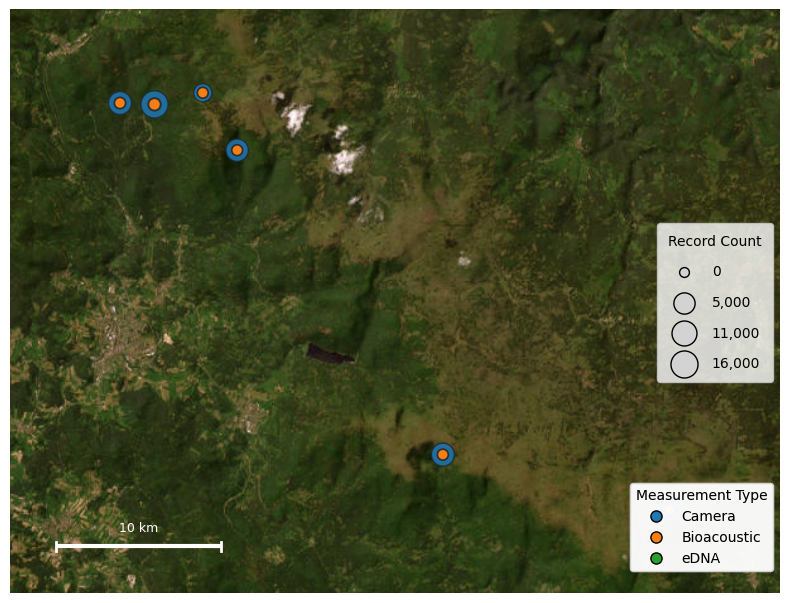

In [5]:
m = station_map(stations, measurement_type="all")

In [11]:
station_explorer(stations, measurement_type="all")

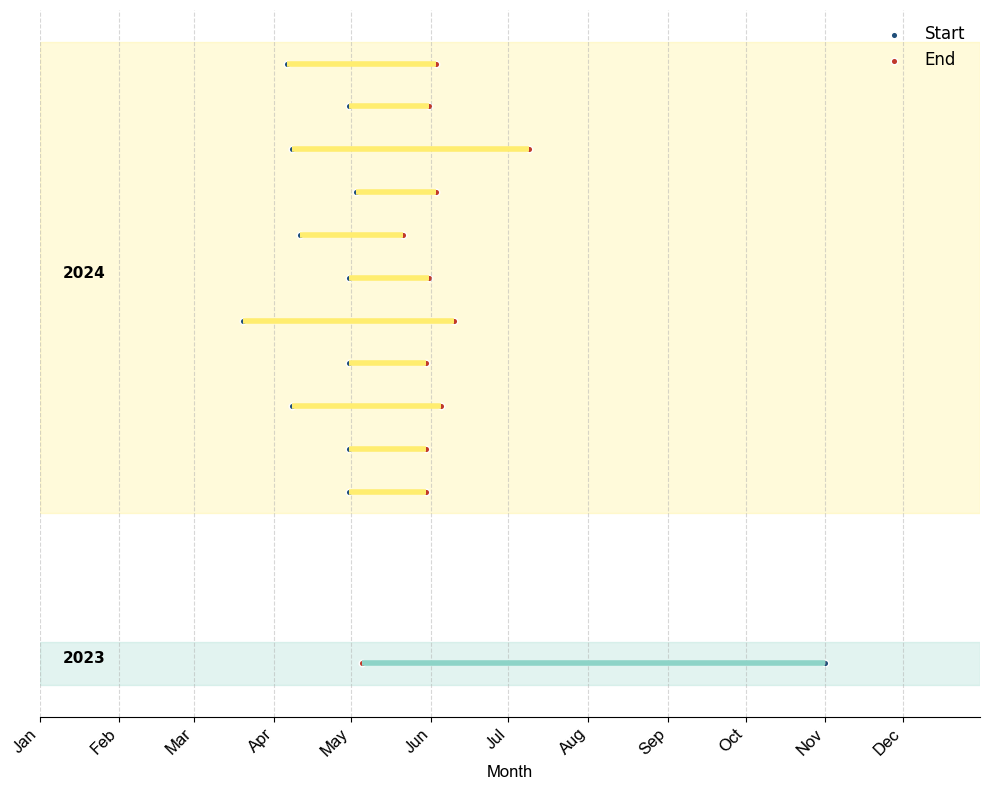

In [6]:
c = camera_activity_timeline(stations)

## 2. Summary of Records and Spcies

In [7]:
camtrap = get_camera_trap_data(hdr)

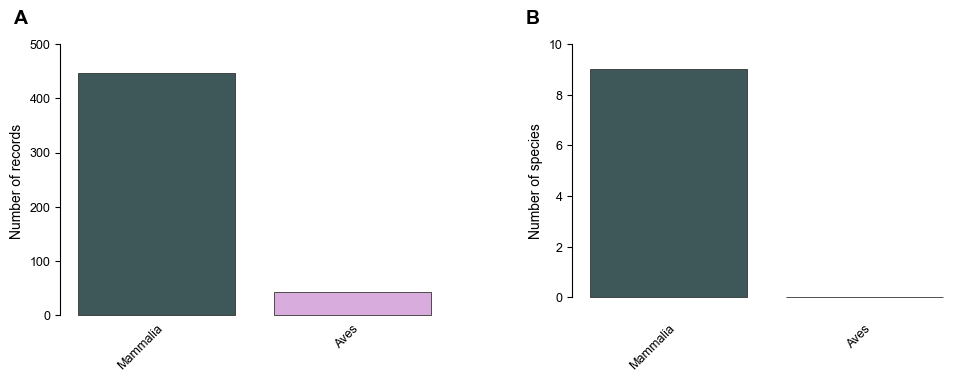

In [8]:
p = records_per_class(camtrap, class_levels=camtrap['class'].unique())

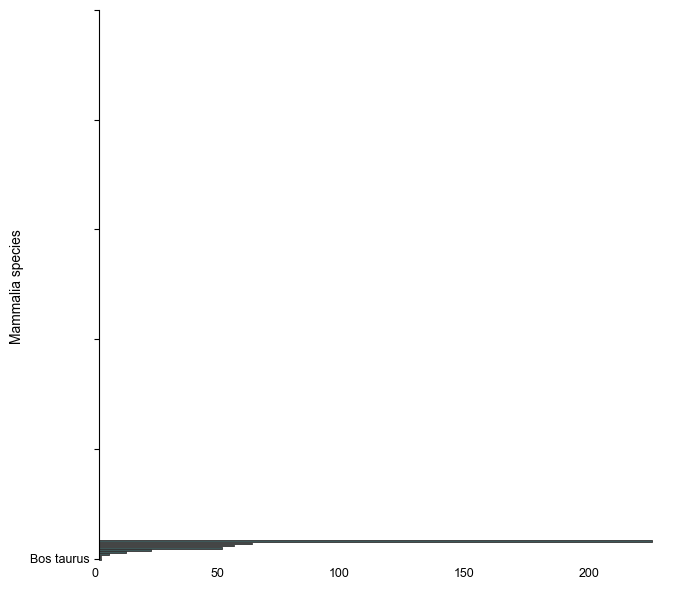

In [10]:
p = plot_top_species(camtrap, top_n=10)

In [10]:
audio = get_audio_observation_data(hdr)

KeyboardInterrupt: 

## 3. Species Accumulation Curves

## Table 2: Redlist Status for All Species

In [ ]:
redlist_table = redlist_status_table(bundle.all_species)
redlist_table

,species,common_name,iucn_redlist_status,sensor_types
0,Gorilla gorilla,Western Gorilla,Critically Endangered,"Camera, eDNA"
1,Loxodonta cyclotis,African Forest Elephant,Critically Endangered,"Camera, eDNA"
2,Enteromius condei,Enteromius condei,Data Deficient,eDNA
3,Oryctolagus cuniculus,European Rabbit,Endangered,eDNA
4,Pan troglodytes,Chimpanzee,Endangered,Camera
...,...,...,...,...
258,Osteolaemus tetraspis,African Dwarf Crocodile,Vulnerable,eDNA
259,Panthera pardus,Leopard,Vulnerable,"Camera, eDNA"
260,Paramormyrops gabonensis,Paramormyrops gabonensis,Vulnerable,eDNA
261,Paramormyrops hopkinsi,Paramormyrops hopkinsi,Vulnerable,eDNA


## Table 3: Major Concern Species

In [ ]:
major_concern_table = major_concern_species_table(bundle.all_species, top_n=10)
major_concern_table

,species,common_name,iucn_redlist_status,sensor_types,observation_count
0,Loxodonta cyclotis,African Forest Elephant,Critically Endangered,"Camera, eDNA",602
1,Gorilla gorilla,Western Gorilla,Critically Endangered,"Camera, eDNA",73
2,Pan troglodytes,Chimpanzee,Endangered,Camera,218
3,Psittacus erithacus,Grey Parrot,Endangered,"Bioacoustic, Camera, eDNA",6
4,Smutsia gigantea,Giant Ground Pangolin,Endangered,"Camera, eDNA",5
5,Stomatorhinus ivindoensis,Stomatorhinus ivindoensis,Endangered,eDNA,3
6,Parananochromis ornatus,Parananochromis ornatus,Endangered,eDNA,2
7,Oryctolagus cuniculus,European Rabbit,Endangered,eDNA,1
8,Cephalophus silvicultor,Yellow-backed Duiker,Near Threatened,"Camera, eDNA",424
9,Syncerus caffer,African Buffalo,Near Threatened,"Camera, eDNA",47


## Export full report suite

In [ ]:
from naturecubepy import generate_reports

report_output_dir = Path.cwd() / 'tutorials' / 'report_output'

# Assets only (data caches, figures, tables, science text).
# Delivery DOCX assembly lives in OkalaReporter.
report_result = generate_reports(
    hdr,
    output_dir=report_output_dir,
    data_dir=report_output_dir / 'data',
    top_n=10,
    write_markdown=True,
)

print('Report asset export complete')
print('Output directory:', report_result.output_dir)
print('Markdown:', report_result.report_markdown)
print('Data files:', len(report_result.data_files))
print('Figures:', len(report_result.figures))
print('Tables:', len(report_result.tables))


{'zoom': 11, 'tile_x_range': [1093, 1095], 'tile_y_range': [1022, 1025], 'tile_count': 12, 'sample_tile_loaded': True, 'sample_tile_shape': (256, 256, 3)}
